# NCAA March Machine Learning Mania 2026 — Complete Pipeline

**Kaggle Competition**: [March Machine Learning Mania 2026](https://kaggle.com/competitions/march-machine-learning-mania-2026)

This notebook provides a complete end-to-end pipeline for predicting NCAA tournament outcomes (both Men's and Women's), evaluated using **Brier Score**.

## Pipeline Overview

| Stage | Description |
|-------|-------------|
| 1 | **Load Data** — Merge men's & women's detailed results, seeds |
| 2 | **Prepare Data** — Normalize for overtime, create symmetric T1/T2 views |
| 3 | **Feature Engineering** — 7 feature families (53 features total) |
| 4 | **Assemble Features** — Merge all onto tournament data |
| 5 | **XGBoost Training** — Leave-one-season-out point margin prediction |
| 6 | **Logistic Calibration** — Grid-searched margin → probability mapping |
| 7 | **Probability Adjustment** — Optimize extreme probabilities for Brier |
| 8 | **Diagnostics** — Per-season evaluation |
| 9 | **Submission** — Generate `predictions.csv` |

## 0. Imports & Configuration

In [6]:
import gc
import warnings
from collections import defaultdict
from itertools import product

import numpy as np
import pandas as pd
import xgboost as xgb
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as tqdm_module

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, mean_absolute_error, roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)

print("All imports successful!")

All imports successful!


In [7]:
# ============================================================
# Configuration — adjust these as needed
# ============================================================
DATA_DIR = "."          # directory containing Kaggle CSV files
MIN_SEASON = 2003       # earliest season to include

# Elo parameters
ELO_BASE = 1000
ELO_WIDTH = 400
ELO_K = 80

# XGBoost hyperparameters (tuned via grid search)
XGB_PARAMS = {
    "objective": "reg:squarederror",
    "booster": "gbtree",
    "tree_method": "hist",
    "grow_policy": "lossguide",
    "eval_metric": "mae",
    "verbosity": 0,
    "seed": 42,
    "num_parallel_tree": 10,
    "gamma": 10,
    "eta": 0.01,
    "max_depth": 3,
    "min_child_weight": 20,
    "subsample": 0.35,
    "colsample_bytree": 0.8,
}
XGB_NUM_ROUNDS = 500

print("Configuration set.")

Configuration set.


## 1. Load Data

Load men's and women's detailed results, tournament results, and seeds. Merge into unified DataFrames.

In [8]:
# Men's data
M_regular_results = pd.read_csv("data/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("data/MNCAATourneyDetailedResults.csv") 
M_seeds = pd.read_csv("data/MNCAATourneySeeds.csv")

# Women's data
W_regular_results = pd.read_csv("data/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv("data/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv("data/WNCAATourneySeeds.csv")

# Merge men's + women's
regular_results = pd.concat([M_regular_results, W_regular_results], ignore_index=True)
tourney_results = pd.concat([M_tourney_results, W_tourney_results], ignore_index=True)
seeds = pd.concat([M_seeds, W_seeds], ignore_index=True)

# Filter by minimum season
regular_results = regular_results[regular_results["Season"] >= MIN_SEASON]
tourney_results = tourney_results[tourney_results["Season"] >= MIN_SEASON]  
seeds = seeds[seeds["Season"] >= MIN_SEASON]

print(f"Regular season games: {len(regular_results):,}")
print(f"Tournament games:     {len(tourney_results):,}") 
print(f"Seeds entries:        {len(seeds):,}")
print(f"Season range:         {regular_results['Season'].min()} - {regular_results['Season'].max()}")

Regular season games: 208,280
Tournament games:     2,410
Seeds entries:        2,896
Season range:         2003 - 2026


## 2. Prepare Data

**Key steps:**
- Map `WLoc` → numeric Home/Away indicator (H=1, A=−1, N=NaN)
- Normalize box scores for overtime (scale by 40/(40+5·NumOT))
- Create symmetric T1/T2 view by doubling each game (swap winner/loser)
- Compute `PointDiff`, `win`, `men_women` flags

In [9]:
# Home/Away encoding
wloc = {'H': 1, 'A': -1, 'N': np.nan}
regular_results['WHome'] = regular_results['WLoc'].map(wloc)
tourney_results['WHome'] = tourney_results['WLoc'].map(wloc)

print("Home/Away encoded.")
print(f"Regular WHome distribution:\n{regular_results['WHome'].value_counts(dropna=False)}")

Home/Away encoded.
Regular WHome distribution:
WHome
 1.0    119478
-1.0     68615
 NaN     20187
Name: count, dtype: int64


In [10]:
def prepare_data(df):
    """
    Normalize for overtime, create symmetric T1/T2 view,
    compute PointDiff, win indicator, and men_women flag.
    """
    cols_keep = [
        "Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore",
        "NumOT", "WHome",
        "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA",
        "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
        "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA",
        "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF",
    ]
    df = df[cols_keep].copy()

    # Overtime adjustment: scale stats to 40-minute equivalent
    adjot = (40 + 5 * df["NumOT"]) / 40
    stat_cols = [c for c in cols_keep if c not in ("Season", "DayNum", "NumOT", "WHome")]
    for col in stat_cols:
        df[col] = df[col] / adjot

    # Create mirrored copy (swap W/L → T1/T2 and L/W → T1/T2)
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in df.columns]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in dfswap.columns]

    # Fix home/away for swapped rows
    df["T2_Home"] = -df["T1_Home"]
    dfswap["T1_Home"] = -dfswap["T2_Home"]

    output = pd.concat([df, dfswap], ignore_index=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0).astype(int)
    # Men's TeamIDs: 1000-1999 → men_women=1 ; Women's: 3000-3999 → men_women=0
    output["men_women"] = output["T1_TeamID"].apply(
        lambda t: 1 if str(int(t)).startswith("1") else 0
    )
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

print(f"Regular data (doubled): {regular_data.shape}")
print(f"Tourney data (doubled): {tourney_data.shape}")

Regular data (doubled): (416560, 38)
Tourney data (doubled): (4820, 38)


In [11]:
# Keep only the columns we need for regular data
reg_cols = [
    "Season", "DayNum", "T1_TeamID", "T1_Score", "T2_TeamID", "T2_Score",
    "NumOT", "PointDiff", "win", "men_women",
    "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF", "T1_Home",
    "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF", "T2_Home",
]
regular_data = regular_data[reg_cols]
regular_data.head()

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,NumOT,PointDiff,win,men_women,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_Home
0,2003,10,1104.0,68.0,1328.0,62.0,0,6.0,1,1,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,NaN,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,NaN
1,2003,10,1272.0,70.0,1393.0,63.0,0,7.0,1,1,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,NaN,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,NaN
2,2003,11,1266.0,73.0,1437.0,61.0,0,12.0,1,1,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,NaN,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,NaN
3,2003,11,1296.0,56.0,1457.0,50.0,0,6.0,1,1,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,NaN,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,NaN
4,2003,11,1400.0,77.0,1208.0,71.0,0,6.0,1,1,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,NaN,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,NaN


## 3. Feature Engineering

### 3.1 Seeds

Extract numeric seed from the seed string (e.g., "W01" → 1) and merge to tournament data.

In [12]:
# Extract numeric seed
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))

seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

# Reduce tourney_data to key columns and merge seeds
tourney_data = tourney_data[
    ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]
].copy()
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

print(f"Tourney data with seeds: {tourney_data.shape}")
tourney_data.head()

Tourney data with seeds: (4820, 9)


,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1263.111111,1254.222222,7.111111,1,1,NaN,NaN,NaN
1,2003,1112.000000,1436.000000,29.000000,1,1,1.0,16.0,15.0
2,2003,1113.000000,1272.000000,13.000000,1,1,10.0,7.0,-3.0
3,2003,1141.000000,1166.000000,6.000000,1,1,11.0,6.0,-5.0
4,2003,1016.000000,1156.444444,1.777778,1,1,NaN,NaN,NaN


#### Seed Predictiveness

Visualize how seed correlates with point differential — lower seeds (better teams) tend to win by more.

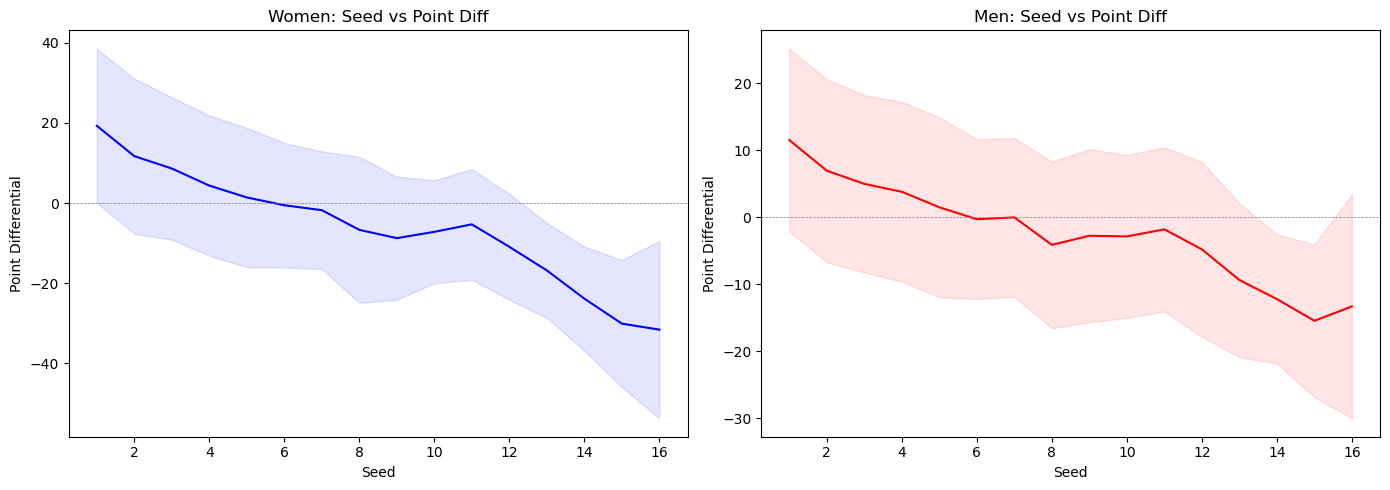

In [13]:
# Seed vs PointDiff
tmpmean = tourney_data.pivot_table(
    columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean"
).ffill()
tmpstd = tourney_data.pivot_table(
    columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std"
).ffill()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mw, color, label in [(axes[0], 0, "blue", "Women"), (axes[1], 1, "red", "Men")]:
    ax.plot(tmpmean.index, tmpmean[mw], f"{color[0]}-")
    ax.fill_between(tmpmean.index, tmpmean[mw] - tmpstd[mw], tmpmean[mw] + tmpstd[mw],
                    color=color, alpha=0.1)
    ax.set_xlabel("Seed")
    ax.set_ylabel("Point Differential")
    ax.set_title(f"{label}: Seed vs Point Diff")
    ax.axhline(0, color="gray", lw=0.5, ls="--")

plt.tight_layout()
plt.show()

### 3.2 Last-14-Day Win Ratio

Captures recent form: win ratio in games played after DayNum > 118 (roughly last 2 weeks of regular season).

In [14]:
# Compute win/play indicators for last 14 days
regular_data['win14days'] = (
    (regular_data['DayNum'] > 118) & (regular_data['T1_Score'] > regular_data['T2_Score'])
).astype(int)
regular_data['last14days'] = (regular_data['DayNum'] > 118).astype(int)

def summarize_14d(x):
    return pd.Series({
        'WinRatio14d': x['win14days'].sum() / (1 + x['last14days'].sum())
    })

ss_new = regular_data.groupby(['Season', 'T1_TeamID']).apply(
    summarize_14d, include_groups=False
).reset_index()
ss_new['season_team'] = ss_new['Season'].astype(str) + '_' + ss_new['T1_TeamID'].astype(str)
ratio_dict = dict(zip(ss_new['season_team'], ss_new['WinRatio14d']))

print(f"Win ratio entries: {len(ratio_dict):,}")
print(f"Sample: {list(ratio_dict.items())[:3]}")

Win ratio entries: 26,927
Sample: [('2003_735.3333333333334', 0.0), ('2003_805.0909090909091', 0.0), ('2003_808.0', 0.0)]


### 3.3 Head-to-Head Matchup Probability (Laplace Smoothed)

For each pair of teams within a season, compute win probability from regular-season matchups. Uses Laplace smoothing (prior of [1,1]) to handle teams that never played.

In [15]:
s = regular_data['Season'].tolist()
t1 = regular_data['T1_TeamID'].tolist()
t2 = regular_data['T2_TeamID'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()

# Record head-to-head results with Laplace prior [1,1]
d = defaultdict(lambda: [1, 1])
for i in range(len(s)):
    key = f"{s[i]}_{t1[i]}_{t2[i]}"
    if s1[i] > s2[i]:
        d[key][0] += 1
    else:
        d[key][1] += 1

# Convert to probabilities
match_dict = defaultdict(lambda: 0.5)
for k, v in d.items():
    match_dict[k] = v[0] / (v[0] + v[1])

print(f"Matchup entries: {len(match_dict):,}")
print("done")

Matchup entries: 309,866
done


### 3.4 Away Win Ratio

Win percentage in away games — captures a team's ability to win on the road (relevant since tournament games are neutral site).

In [16]:
l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1_scores = regular_data['T1_Score'].tolist()
s2_scores = regular_data['T2_Score'].tolist()
h1 = regular_data['T1_Home'].tolist()
h2 = regular_data['T2_Home'].tolist()

away_stat_dict = defaultdict(lambda: [0, 0])

# T1 perspective: won/lost while away
for i in range(len(l1)):
    k = f"{s0[i]}_{l1[i]}"
    if s1_scores[i] > s2_scores[i] and h1[i] == -1:
        away_stat_dict[k][0] += 1
    elif s1_scores[i] < s2_scores[i] and h1[i] == -1:
        away_stat_dict[k][1] += 1

# T2 perspective: won/lost while away
for i in range(len(l2)):
    k = f"{s0[i]}_{l2[i]}"
    if s1_scores[i] < s2_scores[i] and h2[i] == -1:
        away_stat_dict[k][0] += 1
    elif s1_scores[i] > s2_scores[i] and h2[i] == -1:
        away_stat_dict[k][1] += 1

away_dict = {}
for k, v in away_stat_dict.items():
    total = v[0] + v[1]
    away_dict[k] = v[0] / total if total > 0 else 0.5

print(f"Away win entries: {len(away_dict):,}")
print("done")

Away win entries: 21,593
done


### 3.5 Strength-of-Schedule Adjusted Win Rate

Two-pass computation:
1. **Pass 1**: Raw win rate per team per season
2. **Pass 2**: Adjust each win/loss by opponent's win rate — beating a strong opponent counts more

In [17]:
l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1_sc = regular_data['T1_Score'].tolist()
s2_sc = regular_data['T2_Score'].tolist()

# Pass 1: raw win rate
stat_dict = defaultdict(list)
for i in range(len(l1)):
    k = f"{s0[i]}_{l1[i]}"
    stat_dict[k].append(1 if s1_sc[i] > s2_sc[i] else 0)

awins_dict_raw = defaultdict(lambda: np.nan)
for k, v in stat_dict.items():
    awins_dict_raw[k] = np.mean(v)

# Pass 2: opponent-strength adjustment
stat_dict2 = defaultdict(list)
for i in range(len(l1)):
    k = f"{s0[i]}_{l1[i]}"
    opp_key = f"{s0[i]}_{l2[i]}"
    if s1_sc[i] < s2_sc[i]:
        stat_dict2[k].append(-(1 - awins_dict_raw[opp_key]))
    else:
        stat_dict2[k].append(awins_dict_raw[opp_key])

awins_dict = defaultdict(lambda: np.nan)
for k, v in stat_dict2.items():
    awins_dict[k] = np.mean(v)

print(f"SOS-adjusted win rate entries: {len(awins_dict):,}")
print("done")

SOS-adjusted win rate entries: 26,927
done


### 3.6 Advanced Box-Score Rate Features

Compute per-team season aggregates from regular season detailed results:

| Feature | Formula | Meaning |
|---------|---------|---------|
| eFG | (FGM + 0.5·FGM3) / FGA | Effective field goal % |
| FGR3 | FGM3 / FGA3 | 3-point shooting % |
| FTR | FTA / FGA | Free throw rate (drawing fouls) |
| AstR | Ast / FGM | Assist rate |
| Poss | FGA − OR + TO + 0.44·FTA | Possessions |
| TOR | TO / Poss | Turnover rate |
| ORR | OR / (OR + opp_DR) | Offensive rebound rate |
| DRR | DR / (DR + opp_OR) | Defensive rebound rate |
| OffRtg | 100 · Score / Poss | Offensive rating (pts per 100 poss) |
| DefRtg | 100 · opp_Score / Poss | Defensive rating |

In [18]:
performance = [
    'T1_Score', 'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3',
    'T1_FTM', 'T1_FTA', 'T1_OR', 'T1_DR',
    'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF',
    'PointDiff', 'T2_DR', 'T2_OR',
]

team_data = (
    regular_data.groupby(["Season", "T1_TeamID"])
    .agg(**{col: (col, "sum") for col in performance}, number=("T1_Score", "size"))
    .reset_index()
    .rename(columns={"T1_TeamID": "TeamID"})
)

td = team_data
td["eFG"]  = (td["T1_FGM"] + 0.5 * td["T1_FGM3"]) / td["T1_FGA"]
td["FGR3"] = td["T1_FGM3"] / td["T1_FGA3"]
td["FTR"]  = td["T1_FTA"] / td["T1_FGA"]
td["AstR"] = td["T1_Ast"] / td["T1_FGM"]
td["Poss"] = td["T1_FGA"] - td["T1_OR"] + td["T1_TO"] + 0.44 * td["T1_FTA"]
td["TOR"]  = td["T1_TO"] / td["Poss"]
td["ORR"]  = td["T1_OR"] / (td["T1_OR"] + td["T2_DR"])
td["DRR"]  = td["T1_DR"] / (td["T1_DR"] + td["T2_OR"])
td["Score_avg"]     = td["T1_Score"] / td["number"]
td["PointDiff_avg"] = td["PointDiff"] / td["number"]
td["OffRtg"] = 100 * td["T1_Score"] / td["Poss"]
td["DefRtg"] = 100 * (td["T1_Score"] - td["PointDiff"]) / td["Poss"]

feature_cols = [
    "eFG", "FGR3", "FTR", "AstR", "Poss", "TOR",
    "ORR", "DRR", "Score_avg", "PointDiff_avg", "OffRtg", "DefRtg",
]

team_features = td[["Season", "TeamID"] + feature_cols].copy()
print(f"Team features shape: {team_features.shape}")
team_features.head()

Team features shape: (26927, 14)


,Season,TeamID,eFG,FGR3,FTR,AstR,Poss,TOR,ORR,DRR,Score_avg,PointDiff_avg,OffRtg,DefRtg
0,2003,735.333333,0.466667,0.222222,0.586667,0.484848,66.906667,0.159426,0.212766,0.555556,69.333333,-5.333333,103.626943,111.598246
1,2003,805.090909,0.529851,0.379310,0.298507,0.566667,55.854545,0.143229,0.263158,0.744186,61.818182,0.727273,110.677083,109.375000
2,2003,808.000000,0.661538,0.500000,0.369231,0.540541,70.225455,0.279619,0.193548,0.703704,74.909091,2.181818,106.669428,103.562552
3,2003,836.363636,0.500000,0.377778,0.313253,0.606061,71.592727,0.203169,0.296296,0.806452,72.727273,-2.181818,101.584722,104.632263
4,2003,851.636364,0.484375,0.320000,0.500000,0.518519,57.512727,0.151745,0.255814,0.736842,61.090909,-0.727273,106.221548,107.486090


In [19]:
# Build T1 and T2 feature tables with additional dict-based features
team_features_T1 = team_features.rename(columns={col: f"T1_{col}" for col in feature_cols})
team_features_T1["_key"] = team_features_T1["Season"].astype(str) + "_" + team_features_T1["TeamID"].astype(str)
team_features_T1["T1_away_wins"]    = team_features_T1["_key"].map(away_dict)
team_features_T1["T1_awins"]        = team_features_T1["_key"].map(awins_dict)
team_features_T1["T1_WinRatio14d"]  = team_features_T1["_key"].map(ratio_dict)
team_features_T1.drop(columns="_key", inplace=True)

team_features_T2 = team_features.rename(columns={col: f"T2_{col}" for col in feature_cols})
team_features_T2["_key"] = team_features_T2["Season"].astype(str) + "_" + team_features_T2["TeamID"].astype(str)
team_features_T2["T2_away_wins"]    = team_features_T2["_key"].map(away_dict)
team_features_T2["T2_awins"]        = team_features_T2["_key"].map(awins_dict)
team_features_T2["T2_WinRatio14d"]  = team_features_T2["_key"].map(ratio_dict)
team_features_T2.drop(columns="_key", inplace=True)

print("T1 and T2 feature tables built.")
print(f"T1 columns: {list(team_features_T1.columns)}")

T1 and T2 feature tables built.
T1 columns: ['Season', 'TeamID', 'T1_eFG', 'T1_FGR3', 'T1_FTR', 'T1_AstR', 'T1_Poss', 'T1_TOR', 'T1_ORR', 'T1_DRR', 'T1_Score_avg', 'T1_PointDiff_avg', 'T1_OffRtg', 'T1_DefRtg', 'T1_away_wins', 'T1_awins', 'T1_WinRatio14d']


### 3.7 Elo Ratings

Compute end-of-regular-season Elo for each team using **k=80**, base=1000, width=400. Each season starts fresh at base Elo.

In [21]:
def calc_elo(season):
    elo = {}
    
    # Initialize Elo ratings for all teams
    teams = pd.concat([ss["T1_TeamID"], ss["T2_TeamID"]]).unique()
    for team in teams:
        elo[team] = 1500  # Initialize Elo rating to 1500 for all teams
    
    for i in range(len(ss)):
        w, l = int(ss.loc[i, "T1_TeamID"]), int(ss.loc[i, "T2_TeamID"])
        elo[w], elo[l] = update_elo(elo[w], elo[l], ELO_K)
    
    elo_df = pd.DataFrame({"TeamID": list(elo.keys()), "elo": list(elo.values())})
    elo_df["Season"] = season
    
    return elo_df

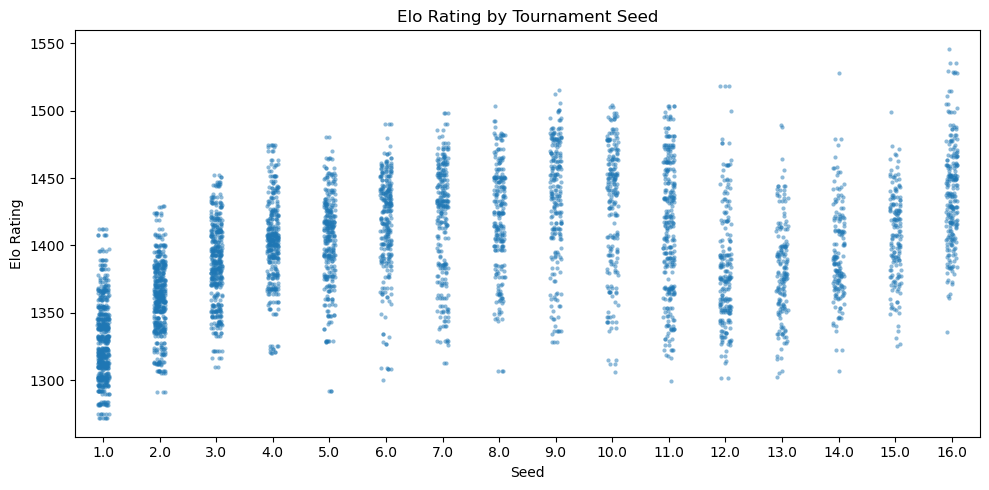

In [24]:
def calc_elo(team_results):
    elo = {}
    
    # Initialize Elo ratings for all teams
    teams = pd.concat([team_results["T1_TeamID"], team_results["T2_TeamID"]]).unique()
    for team in teams:
        elo[team] = 1500  # Initialize Elo rating to 1500 for all teams
    
    for _, row in team_results.iterrows():
        w, l = row["T1_TeamID"], row["T2_TeamID"]
        elo[w], elo[l] = update_elo(elo[w], elo[l], 32)  # Assuming K-factor of 32
    
    elos = pd.DataFrame({"TeamID": list(elo.keys()), "elo": list(elo.values())})
    elos["Season"] = team_results["Season"].iloc[0]  # Assuming all games are from the same season
    
    return elos

# Calculate Elo ratings for each season
elos_list = []
for season, season_data in regular_data.groupby("Season"):
    elos = calc_elo(season_data)
    elos_list.append(elos)

elos = pd.concat(elos_list, ignore_index=True)

# Merge tourney_data with elos based on Season and TeamID
tourney_elo = pd.merge(tourney_data, elos, left_on=["Season", "T1_TeamID"], right_on=["Season", "TeamID"], how="left")

# Rename the 'elo' column to 'T1_elo'
tourney_elo = tourney_elo.rename(columns={"elo": "T1_elo"})

# Visualize Elo by seed
plt.figure(figsize=(10, 5))
sns.stripplot(data=tourney_elo, y='T1_elo', x='T1_seed', size=3, alpha=0.5)
plt.title("Elo Rating by Tournament Seed")
plt.xlabel("Seed")
plt.ylabel("Elo Rating")
plt.tight_layout()
plt.show()

### 3.8 GLM Team Quality

Fit a GLM per season: `PointDiff ~ T1_TeamID + T2_TeamID` on regular-season games involving tournament-caliber teams. The T1 coefficients become each team's "quality" score.

> This is the most compute-intensive feature — may take a few minutes.

In [25]:
# Prepare ST1/ST2 identifiers
regular_data["ST1"] = (
    regular_data["Season"].astype(int).astype(str) + "/"
    + regular_data["T1_TeamID"].astype(int).astype(str)
)
regular_data["ST2"] = (
    regular_data["Season"].astype(int).astype(str) + "/"
    + regular_data["T2_TeamID"].astype(int).astype(str)
)

seeds_T1_glm = seeds_T1.copy()
seeds_T2_glm = seeds_T2.copy()
seeds_T1_glm["ST1"] = seeds_T1_glm["Season"].astype(str) + "/" + seeds_T1_glm["T1_TeamID"].astype(str)
seeds_T2_glm["ST2"] = seeds_T2_glm["Season"].astype(str) + "/" + seeds_T2_glm["T2_TeamID"].astype(str)

# Tourney teams + teams that beat tourney teams
st = set(seeds_T1_glm["ST1"]) | set(seeds_T2_glm["ST2"])
st = st | set(
    regular_data.loc[
        (regular_data["T1_Score"] > regular_data["T2_Score"])
        & (regular_data["ST2"].isin(st)),
        "ST1",
    ]
)

dt = regular_data[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)].copy()
dt["T1_TeamID"] = dt["T1_TeamID"].astype(int).astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(int).astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"

print(f"GLM training data: {len(dt):,} rows")
print(f"Relevant teams (incl. beat-tourney): {len(st):,}")

GLM training data: 300,780 rows
Relevant teams (incl. beat-tourney): 8,388


In [26]:
def team_quality_single(season, mw):
    """Fit GLM for one season and gender, return quality scores."""
    subset = dt[(dt["Season"] == season) & (dt["men_women"] == mw)]
    if len(subset) < 10:
        return pd.DataFrame(columns=["TeamID", "quality", "Season"])
    try:
        formula = "PointDiff ~ -1 + T1_TeamID + T2_TeamID"
        glm = sm.GLM.from_formula(
            formula=formula, data=subset, family=sm.families.Gaussian()
        ).fit()
        quality = pd.DataFrame(glm.params).reset_index()
        quality.columns = ["TeamID", "quality"]
        quality["Season"] = season
        quality = quality[quality["TeamID"].str.contains("T1_")].reset_index(drop=True)
        quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
        return quality
    except Exception as e:
        return pd.DataFrame(columns=["TeamID", "quality", "Season"])

glm_quality_list = []
seasons = sorted(seeds["Season"].unique())
for s in tqdm_module.tqdm(seasons, desc="GLM quality", unit="season"):
    if s >= 2010:
        glm_quality_list.append(team_quality_single(s, 0))  # women
    if s >= 2003:
        glm_quality_list.append(team_quality_single(s, 1))  # men

glm_quality = pd.concat(glm_quality_list, ignore_index=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2 = glm_quality.copy()
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]

print(f"GLM quality computed for {len(glm_quality):,} team-seasons")

GLM quality: 100%|██████████| 22/22 [09:11<00:00, 25.06s/season]

GLM quality computed for 5,327 team-seasons


## 4. Assemble All Features

Merge all 7 feature families onto tournament data and compute T1−T2 difference features.

In [30]:
# Team performance features
tourney_data = tourney_data.merge(
    team_features_T1, left_on=["Season", "T1_TeamID"],
    right_on=["Season", "TeamID"], how="left"
).drop(columns="TeamID")
tourney_data = tourney_data.merge(
    team_features_T2, left_on=["Season", "T2_TeamID"],
    right_on=["Season", "TeamID"], how="left"
).drop(columns="TeamID")

# Head-to-head matchup probability
tourney_data["laplace_matchup"] = (
    tourney_data["Season"].astype(str) + "_"
    + tourney_data["T1_TeamID"].astype(str) + "_"
    + tourney_data["T2_TeamID"].astype(str)
).map(match_dict)

# Feature diffs
for col in feature_cols:
    tourney_data[f"{col}_diff"] = tourney_data[f"T1_{col}"] - tourney_data[f"T2_{col}"]

# Elo
elos_T1 = elos.rename(columns={"TeamID": "T1_TeamID", "elo": "T1_elo"})
elos_T2 = elos.rename(columns={"TeamID": "T2_TeamID", "elo": "T2_elo"})
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

# GLM quality
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

print(f"Final tourney data: {tourney_data.shape}")
tourney_data.head()

Final tourney data: (4820, 118)


,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_eFG_x,T1_FGR3_x,T1_FTR_x,T1_AstR_x,T1_Poss_x,T1_TOR_x,T1_ORR_x,T1_DRR_x,T1_Score_avg_x,T1_PointDiff_avg_x,T1_OffRtg_x,T1_DefRtg_x,T1_away_wins_x,T1_awins_x,T1_WinRatio14d_x,T2_eFG_x,T2_FGR3_x,T2_FTR_x,T2_AstR_x,T2_Poss_x,T2_TOR_x,T2_ORR_x,T2_DRR_x,T2_Score_avg_x,T2_PointDiff_avg_x,T2_OffRtg_x,T2_DefRtg_x,T2_away_wins_x,T2_awins_x,T2_WinRatio14d_x,laplace_matchup,eFG_diff,FGR3_diff,FTR_diff,AstR_diff,Poss_diff,TOR_diff,ORR_diff,DRR_diff,Score_avg_diff,PointDiff_avg_diff,OffRtg_diff,DefRtg_diff,T1_eFG_y,T1_FGR3_y,T1_FTR_y,T1_AstR_y,T1_Poss_y,T1_TOR_y,T1_ORR_y,T1_DRR_y,T1_Score_avg_y,T1_PointDiff_avg_y,T1_OffRtg_y,T1_DefRtg_y,T1_away_wins_y,T1_awins_y,T1_WinRatio14d_y,T2_eFG_y,T2_FGR3_y,T2_FTR_y,T2_AstR_y,T2_Poss_y,T2_TOR_y,T2_ORR_y,T2_DRR_y,T2_Score_avg_y,T2_PointDiff_avg_y,T2_OffRtg_y,T2_DefRtg_y,T2_away_wins_y,T2_awins_y,T2_WinRatio14d_y,T1_eFG,T1_FGR3,T1_FTR,T1_AstR,T1_Poss,T1_TOR,T1_ORR,T1_DRR,T1_Score_avg,T1_PointDiff_avg,T1_OffRtg,T1_DefRtg,T1_away_wins,T1_awins,T1_WinRatio14d,T2_eFG,T2_FGR3,T2_FTR,T2_AstR,T2_Poss,T2_TOR,T2_ORR,T2_DRR,T2_Score_avg,T2_PointDiff_avg,T2_OffRtg,T2_DefRtg,T2_away_wins,T2_awins,T2_WinRatio14d,T1_elo,T2_elo,elo_diff,T1_quality,T2_quality,diff_quality
0,2003,1263.111111,1254.222222,7.111111,1,1,NaN,NaN,NaN,0.544041,0.472727,0.269430,0.521739,202.560000,0.236967,0.381818,0.679688,73.481481,3.851852,108.829208,103.124451,1.000000,0.333333,0.666667,0.465517,0.352941,0.637931,0.666667,66.915556,0.239107,0.425000,0.702128,64.000000,4.444444,95.642933,89.001063,NaN,0.000000,0.00,0.5,0.078524,0.119786,-0.368501,-0.144928,135.644444,-0.002141,-0.043182,-0.022440,9.481481,-0.592593,13.186275,14.123389,0.544041,0.472727,0.269430,0.521739,202.560000,0.236967,0.381818,0.679688,73.481481,3.851852,108.829208,103.124451,1.000000,0.333333,0.666667,0.465517,0.352941,0.637931,0.666667,66.915556,0.239107,0.425000,0.702128,64.000000,4.444444,95.642933,89.001063,NaN,0.000000,0.00,0.544041,0.472727,0.269430,0.521739,202.560000,0.236967,0.381818,0.679688,73.481481,3.851852,108.829208,103.124451,1.000000,0.333333,0.666667,0.465517,0.352941,0.637931,0.666667,66.915556,0.239107,0.425000,0.702128,64.000000,4.444444,95.642933,89.001063,NaN,0.000000,0.00,1493.261359,1497.803475,-4.542117,NaN,NaN,NaN
1,2003,1112.0,1436.0,29.000000,1,1,1.0,16.0,15.0,0.520542,0.360376,0.386507,0.577977,2018.026667,0.197332,0.396717,0.680200,83.888889,15.732510,112.238358,91.189193,0.909091,0.473526,0.750000,0.491972,0.349057,0.348105,0.572254,1825.480000,0.217477,0.378741,0.729566,67.428571,5.000000,103.424853,95.755637,0.500000,0.117517,0.75,0.5,0.028570,0.011319,0.038401,0.005722,192.546667,-0.020145,0.017976,-0.049366,16.460317,10.732510,8.813506,-4.566444,0.520542,0.360376,0.386507,0.577977,2018.026667,0.197332,0.396717,0.680200,83.888889,15.732510,112.238358,91.189193,0.909091,0.473526,0.750000,0.491972,0.349057,0.348105,0.572254,1825.480000,0.217477,0.378741,0.729566,67.428571,5.000000,103.424853,95.755637,0.500000,0.117517,0.75,0.520542,0.360376,0.386507,0.577977,2018.026667,0.197332,0.396717,0.680200,83.888889,15.732510,112.238358,91.189193,0.909091,0.473526,0.750000,0.491972,0.349057,0.348105,0.572254,1825.480000,0.217477,0.378741,0.729566,67.428571,5.000000,103.424853,95.755637,0.500000,0.117517,0.75,1345.999613,1415.801276,-69.801663,24.530423,9.023634,15.506790
2,2003,1113.0,1272.0,13.000000,1,1,10.0,7.0,-3.0,0.516993,0.327381,0.440523,0.576087,1853.560000,0.202313,0.388393,0.674595,75.592593,7.074074,110.112432,99.807937,0.333333,0.187139,0.500000,0.503541,0.348327,0.374859,0.623137,2081.453333,0.204238,0.372622,0.680089,74.048148,8.611111,106.725643,94.314443,0.583333,0.319738,0.50,0.5,0.013453,-0.020946,0.065664,-0.047051,-227.893333,-0.001924,0.015770,-0.005494,1.544444,-1.537037,3.386790,5.493494,0.516993,0.327381,0.440523,0.576087,1853.560000,0.202313,0.388393,0.674595,75.592593,7.074074,110.112432,99.807937,0.333333,0.187139,0.500000,0.503541,0.34

In [31]:
# Define the full feature list (53 features)
features = [
    "men_women",
    # T1 features
    "T1_seed", "T1_elo", "T1_quality",
    "T1_eFG", "T1_FGR3", "T1_FTR", "T1_AstR", "T1_Poss", "T1_TOR",
    "T1_ORR", "T1_DRR", "T1_Score_avg", "T1_PointDiff_avg",
    "T1_OffRtg", "T1_DefRtg", "T1_WinRatio14d", "T1_away_wins", "T1_awins",
    # T2 features
    "T2_seed", "T2_elo", "T2_quality",
    "T2_eFG", "T2_FGR3", "T2_FTR", "T2_AstR", "T2_Poss", "T2_TOR",
    "T2_ORR", "T2_DRR", "T2_Score_avg", "T2_PointDiff_avg",
    "T2_OffRtg", "T2_DefRtg", "T2_WinRatio14d", "T2_away_wins", "T2_awins",
    # Differences
    "Seed_diff", "elo_diff", "diff_quality", "laplace_matchup",
    "eFG_diff", "FGR3_diff", "FTR_diff", "AstR_diff", "Poss_diff", "TOR_diff",
    "ORR_diff", "DRR_diff", "Score_avg_diff", "PointDiff_avg_diff",
    "OffRtg_diff", "DefRtg_diff",
]

print(f"Number of features: {len(features)}")

Number of features: 53


### Feature Quality Check

In [32]:
# Check Seed AUC and Quality AUC
try:
    seed_auc = roc_auc_score(
        1 - tourney_data["win"],
        tourney_data["T1_seed"] - tourney_data["T2_seed"]
    )
    quality_auc = roc_auc_score(
        tourney_data["win"],
        tourney_data["T1_quality"] - tourney_data["T2_quality"]
    )
    print(f"Seed AUC:    {seed_auc:.3f}")
    print(f"Quality AUC: {quality_auc:.3f}")
except Exception as e:
    print(f"AUC computation error: {e}")

# Per-season comparison: seed vs quality
print("\nSeason | Seed AUC | Quality AUC | Winner")
print("-" * 50)
for s in sorted(tourney_data['Season'].unique()):
    mask = tourney_data['Season'] == s
    try:
        a = np.round(roc_auc_score(1 - tourney_data.loc[mask, "win"],
                                    tourney_data.loc[mask, "T1_seed"] - tourney_data.loc[mask, "T2_seed"]), 3)
        b = np.round(roc_auc_score(tourney_data.loc[mask, "win"],
                                    tourney_data.loc[mask, "T1_quality"] - tourney_data.loc[mask, "T2_quality"]), 3)
        winner = "Quality" if b > a else "Seed"
        print(f"  {s}  |  {a:.3f}   |   {b:.3f}     | {winner}")
    except:
        pass

AUC computation error: Input contains NaN.

Season | Seed AUC | Quality AUC | Winner
--------------------------------------------------


## 5. XGBoost Training (Leave-One-Season-Out)

Train XGBoost to predict **point margin** (not win probability directly). Each season is held out once for validation. All models are kept for the final ensemble.

In [33]:
models = {}
oof_mae = []
tourney_data["pred_margin"] = np.nan

for oof_season in sorted(tourney_data["Season"].unique()):
    train_mask = tourney_data["Season"] != oof_season
    val_mask = tourney_data["Season"] == oof_season

    x_train = tourney_data.loc[train_mask, features].values
    y_train = tourney_data.loc[train_mask, "PointDiff"].values
    x_val = tourney_data.loc[val_mask, features].values
    y_val = tourney_data.loc[val_mask, "PointDiff"].values

    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)

    models[oof_season] = xgb.train(
        params=XGB_PARAMS, dtrain=dtrain, num_boost_round=XGB_NUM_ROUNDS
    )

    preds = models[oof_season].predict(dval)
    tourney_data.loc[val_mask, "pred_margin"] = preds

    mae = mean_absolute_error(y_val, preds)
    oof_mae.append(mae)
    print(f"Season {oof_season}: MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(oof_mae):.4f}")

Season 2003: MAE = 8.7229
Season 2004: MAE = 7.7524
Season 2005: MAE = 7.7882
Season 2006: MAE = 8.6200
Season 2007: MAE = 7.8540
Season 2008: MAE = 9.5343
Season 2009: MAE = 8.6572
Season 2010: MAE = 8.7069
Season 2011: MAE = 9.6949
Season 2012: MAE = 8.2352
Season 2013: MAE = 9.9285
Season 2014: MAE = 9.8836
Season 2015: MAE = 7.6818
Season 2016: MAE = 10.2011
Season 2017: MAE = 9.8590
Season 2018: MAE = 10.5483
Season 2019: MAE = 9.2074
Season 2021: MAE = 10.0180
Season 2022: MAE = 10.3531
Season 2023: MAE = 9.7140
Season 2024: MAE = 9.3088
Season 2025: MAE = 10.3186

Average MAE: 9.2086


## 6. Logistic Calibration

Map the predicted point margin to a win probability using **LogisticRegression**. Grid-search over C, solver, penalty, class_weight to minimize Brier score.

In [34]:
C_grid = np.logspace(-4, 2, 13)
solvers = ["liblinear", "lbfgs", "saga"]
penalties = ["l1", "l2"]
class_weights = [None, "balanced"]

best_logistic_brier = np.inf
best_logistic_params = None
best_logistic_oof_prob = None
best_logistic_models = None

seasons = sorted(tourney_data["Season"].unique())

for C, solver, penalty, cw in product(C_grid, solvers, penalties, class_weights):
    if penalty == "l1" and solver not in ("liblinear", "saga"):
        continue

    oof_prob = np.full(len(tourney_data), np.nan)
    lr_models = {}

    try:
        for oof_season in seasons:
            train_idx = tourney_data["Season"] != oof_season
            val_idx = tourney_data["Season"] == oof_season

            x_tr = tourney_data.loc[train_idx, "pred_margin"].values.reshape(-1, 1)
            y_tr = tourney_data.loc[train_idx, "win"].values
            x_va = tourney_data.loc[val_idx, "pred_margin"].values.reshape(-1, 1)

            lr = LogisticRegression(
                C=C, solver=solver, penalty=penalty,
                class_weight=cw, max_iter=1000, random_state=0
            )
            lr.fit(x_tr, y_tr)
            lr_models[oof_season] = lr
            prob_val = np.clip(lr.predict_proba(x_va)[:, 1], 0.01, 0.99)
            oof_prob[val_idx] = prob_val
    except Exception:
        continue

    brier = brier_score_loss(tourney_data["win"], oof_prob)
    if brier < best_logistic_brier:
        best_logistic_brier = brier
        best_logistic_params = {"C": C, "solver": solver, "penalty": penalty, "class_weight": cw}
        best_logistic_oof_prob = oof_prob.copy()
        best_logistic_models = lr_models.copy()

print(f"Best Logistic params: {best_logistic_params}")
print(f"Best Logistic OOF Brier: {best_logistic_brier:.6f}")

Best Logistic params: {'C': np.float64(0.001), 'solver': 'saga', 'penalty': 'l2', 'class_weight': None}
Best Logistic OOF Brier: 0.167940


## 7. Probability Adjustment

Fine-tune extreme probabilities (near 0 or 1) to improve Brier score. This addresses the model's tendency to be over-confident or under-confident on strong favorites / heavy underdogs.

In [35]:
def adjust_probability(p, upper_threshold, upper_delta, lower_threshold, lower_delta):
    """Scale probabilities near 0/1 to improve Brier score."""
    p_new = p.copy()
    p_new[p_new >= upper_threshold] *= (1 + upper_delta)
    p_new[p_new <= lower_threshold] *= (1 - lower_delta)
    return np.clip(p_new, 0.001, 0.999)

upper_threshold_list = [0.7, 0.75, 0.8, 0.85, 0.9]
upper_delta_list = [-0.15, -0.12, -0.10, -0.08, -0.07, -0.05, -0.03, -0.01,
                     0.01,  0.03,  0.05,  0.07,  0.08,  0.10,  0.12,  0.15]
lower_threshold_list = [0.3, 0.25, 0.2, 0.15, 0.1]
lower_delta_list = [-0.15, -0.12, -0.10, -0.08, -0.07, -0.05, -0.03, -0.01,
                     0.01,  0.03,  0.05,  0.07,  0.08,  0.10,  0.12,  0.15]

best_manual_brier = best_logistic_brier
best_manual_params = {"upper_threshold": 0, "upper_delta": 0,
                      "lower_threshold": 0, "lower_delta": 0}
best_manual_prob = best_logistic_oof_prob.copy()

for ut in upper_threshold_list:
    for ud in upper_delta_list:
        for lt in lower_threshold_list:
            for ld in lower_delta_list:
                adj = adjust_probability(best_logistic_oof_prob, ut, ud, lt, ld)
                brier = brier_score_loss(tourney_data["win"], adj)
                if brier < best_manual_brier:
                    best_manual_brier = brier
                    best_manual_params = {
                        "upper_threshold": ut, "upper_delta": ud,
                        "lower_threshold": lt, "lower_delta": ld,
                    }
                    best_manual_prob = adj.copy()

if best_manual_params["upper_threshold"] == 0:
    final_adj_params = {"upper_threshold": 0, "upper_delta": 0,
                        "lower_threshold": 0, "lower_delta": 0}
    final_prob = best_logistic_oof_prob.copy()
    final_brier = best_logistic_brier
    print("No adjustment improves baseline.")
else:
    final_adj_params = best_manual_params
    final_prob = best_manual_prob.copy()
    final_brier = best_manual_brier
    print(f"Adjustment improves Brier!")

print(f"\nBest adjustment params: {final_adj_params}")
print(f"Logistic baseline Brier: {best_logistic_brier:.6f}")
print(f"Final adjusted Brier:    {final_brier:.6f}")

Adjustment improves Brier!

Best adjustment params: {'upper_threshold': 0.8, 'upper_delta': 0.01, 'lower_threshold': 0.2, 'lower_delta': 0.12}
Logistic baseline Brier: 0.167940
Final adjusted Brier:    0.167875


## 8. Diagnostics

Evaluate final OOF predictions per season.

Overall OOF Brier Score: 0.167875

Per-season Brier scores:
----------------------------------------
  2003: 0.1836 (128 games)
  2004: 0.1703 (128 games)
  2005: 0.1663 (128 games)
  2006: 0.1925 (128 games)
  2007: 0.1440 (128 games)
  2008: 0.1510 (128 games)
  2009: 0.1602 (128 games)
  2010: 0.1690 (254 games)
  2011: 0.1798 (260 games)
  2012: 0.1563 (260 games)
  2013: 0.1804 (260 games)
  2014: 0.1748 (260 games)
  2015: 0.1429 (260 games)
  2016: 0.1874 (260 games)
  2017: 0.1566 (260 games)
  2018: 0.1857 (260 games)
  2019: 0.1615 (260 games)
  2021: 0.1785 (258 games)
  2022: 0.1804 (268 games)
  2023: 0.1819 (268 games)
  2024: 0.1539 (268 games)
  2025: 0.1334 (268 games)


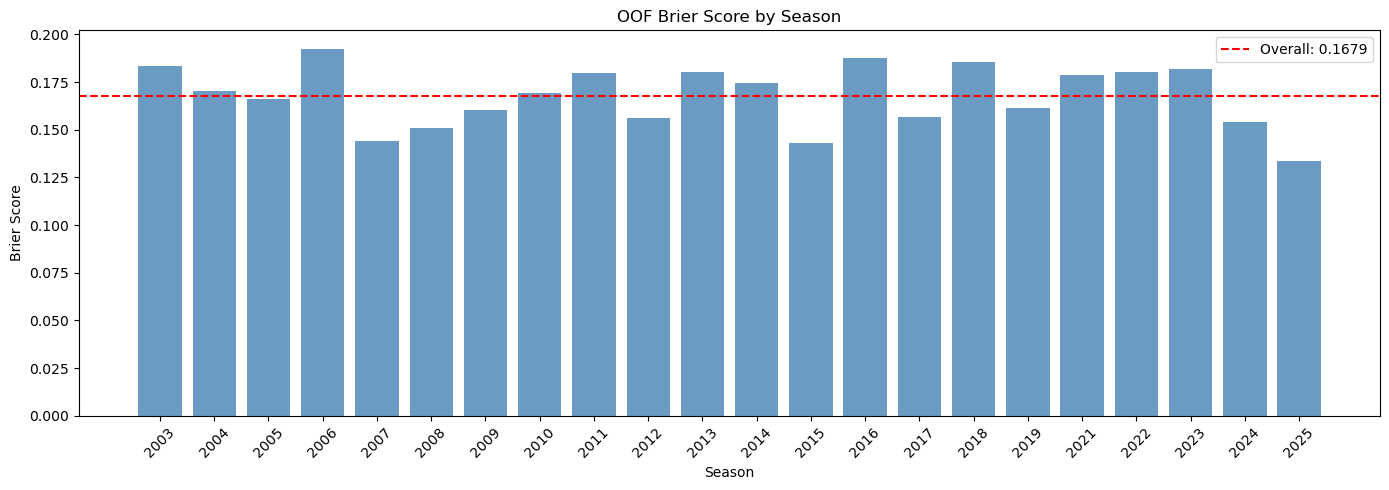

In [36]:
y_true = tourney_data["win"].values
overall_brier = brier_score_loss(y_true, final_prob)
print(f"Overall OOF Brier Score: {overall_brier:.6f}")

print("\nPer-season Brier scores:")
print("-" * 40)
season_briers = []
for s in sorted(tourney_data["Season"].unique()):
    mask = tourney_data["Season"].values == s
    if mask.sum() > 0:
        brier_s = brier_score_loss(y_true[mask], final_prob[mask])
        season_briers.append({"Season": s, "Brier": brier_s, "Games": mask.sum()})
        print(f"  {s}: {brier_s:.4f} ({mask.sum()} games)")

season_df = pd.DataFrame(season_briers)
plt.figure(figsize=(14, 5))
plt.bar(season_df["Season"].astype(str), season_df["Brier"], color="steelblue", alpha=0.8)
plt.axhline(overall_brier, color="red", ls="--", label=f"Overall: {overall_brier:.4f}")
plt.xlabel("Season")
plt.ylabel("Brier Score")
plt.title("OOF Brier Score by Season")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Generate Submission

Build predictions for every possible 2026 matchup. Ensemble across all leave-one-season-out models, calibrate with logistic, adjust probabilities, and save.

In [39]:
X = pd.read_csv("data/SampleSubmissionStage2.csv")
print(f"Submission template: {X.shape}")

# Parse IDs
X['Season']    = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))

# IMPORTANT: men_women must match training convention!
# Men's TeamIDs start with 1 → men_women=1; Women's start with 3 → men_women=0
X['men_women'] = X['T1_TeamID'].apply(lambda t: 1 if str(t).startswith("1") else 0)

print(f"Men matchups:   {(X['men_women']==1).sum():,}")
print(f"Women matchups: {(X['men_women']==0).sum():,}")

Submission template: (132133, 2)
Men matchups:   66,430
Women matchups: 65,703


In [40]:
# Merge team features
X = X.merge(team_features_T1, left_on=["Season", "T1_TeamID"],
            right_on=["Season", "TeamID"], how="left").drop(columns="TeamID")
X = X.merge(team_features_T2, left_on=["Season", "T2_TeamID"],
            right_on=["Season", "TeamID"], how="left").drop(columns="TeamID")

# Seeds
X = pd.merge(X, seeds_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, seeds_T2, on=["Season", "T2_TeamID"], how="left")

# GLM quality
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")

# Elo
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")

# Diffs
X["Seed_diff"]    = X["T2_seed"] - X["T1_seed"]
X["elo_diff"]     = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

# Laplace matchup
X["laplace_matchup"] = (
    X["Season"].astype(str) + "_"
    + X["T1_TeamID"].astype(str) + "_"
    + X["T2_TeamID"].astype(str)
).map(match_dict)

# Feature diffs
for col in feature_cols:
    X[f"{col}_diff"] = X[f"T1_{col}"] - X[f"T2_{col}"]

print(f"Submission data shape: {X.shape}")
print(f"Missing values in features:\n{X[features].isnull().sum().sum()} total NaN cells")

Submission data shape: (132133, 58)
Missing values in features:
792798 total NaN cells


In [41]:
# Ensemble predictions across all leave-one-season-out models
preds_list = []
for oof_season in sorted(tourney_data["Season"].unique()):
    dtest = xgb.DMatrix(X[features].values)
    margin_preds = models[oof_season].predict(dtest)
    probs = best_logistic_models[oof_season].predict_proba(
        margin_preds.reshape(-1, 1)
    )[:, 1]
    probs = adjust_probability(
        probs,
        final_adj_params["upper_threshold"],
        final_adj_params["upper_delta"],
        final_adj_params["lower_threshold"],
        final_adj_params["lower_delta"],
    )
    preds_list.append(probs)

X["Pred"] = np.mean(preds_list, axis=0)
X["Pred"] = X["Pred"].clip(0.01, 0.99).fillna(0.5)

print(f"Prediction stats:")
print(X["Pred"].describe())

Prediction stats:
count    132133.000000
mean          0.503008
std           0.182015
min           0.033716
25%           0.396261
50%           0.502803
75%           0.610551
max           0.974004
Name: Pred, dtype: float64


In [42]:
# Save submission
submission = X[["ID", "Pred"]]
submission.to_csv("predictions.csv", index=False)

print(f"\nSubmission saved: predictions.csv")
print(f"Total matchups: {len(submission):,}")
print(f"\nFirst 10 rows:")
submission.head(10)


Submission saved: predictions.csv
Total matchups: 132,133

First 10 rows:


,ID,Pred
0,2026_1101_1102,0.586237
1,2026_1101_1103,0.191808
2,2026_1101_1104,0.283154
3,2026_1101_1105,0.532658
4,2026_1101_1106,0.461391
5,2026_1101_1107,0.463030
6,2026_1101_1108,0.609047
7,2026_1101_1110,0.457537
8,2026_1101_1111,0.412275
9,2026_1101_1112,0.109946


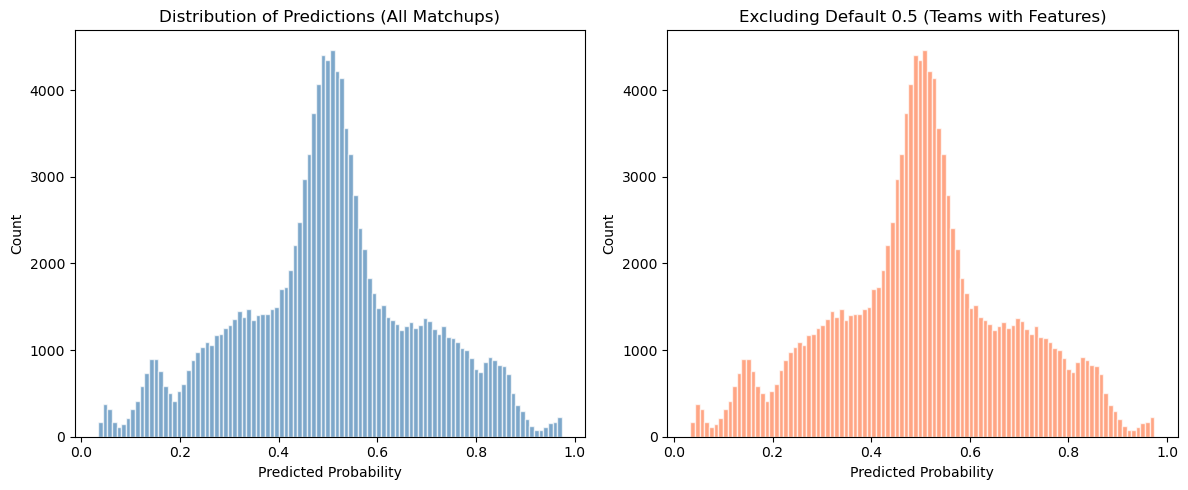

Predictions at exactly 0.5 (no features): 0
Predictions != 0.5 (have features):       132,133


In [43]:
# Distribution of predictions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(X["Pred"], bins=100, color="steelblue", alpha=0.7, edgecolor="white")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Predictions (All Matchups)")

plt.subplot(1, 2, 2)
plt.hist(X.loc[X["Pred"] != 0.5, "Pred"], bins=100, color="coral", alpha=0.7, edgecolor="white")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Excluding Default 0.5 (Teams with Features)")

plt.tight_layout()
plt.show()

print(f"Predictions at exactly 0.5 (no features): {(X['Pred'] == 0.5).sum():,}")
print(f"Predictions != 0.5 (have features):       {(X['Pred'] != 0.5).sum():,}")